# Pick a 30-day BC level window
Compare the full downloaded 2023 season for a ramp-up and a late climax. This is a shortlist for your choice, not a level export. All dates and daily bins are UTC.

## 1. Load FIRMS detections

In [1]:
from pathlib import Path
from collections import deque
import sys
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display

folder = Path.cwd().resolve()
root = next((p for p in (folder, *folder.parents) if (p / "data" / "common.py").is_file()), None)
if root is None:
    raise RuntimeError("Launch from the repository root or data folder.")
sys.path.insert(0, str(root / "data"))
from common import YEAR, START as SEASON_START, END as SEASON_END, PROCESSED_DIR, load_bc_boundary

GRID_DEGREES = 0.05
LOOKBACK_DAYS = 3
WINDOW_DAYS = 30
PEAK_LAST_DAYS = 5
ROLLING_DAYS = 7
firms = pd.read_csv(PROCESSED_DIR / f"firms_bc_{YEAR}.csv",
                    usecols=["acq_datetime", "latitude", "longitude"])
firms["acq_datetime"] = pd.to_datetime(firms.acq_datetime, utc=True)
assert firms.notna().all().all()
firms["day"] = firms.acq_datetime.dt.floor("D")
days = pd.date_range(SEASON_START, SEASON_END, freq="D", tz="UTC")
if not firms.day.isin(days).all():
    raise ValueError("FIRMS dates fall outside the downloaded season in common.py.")
print(f"Rows: {len(firms):,}")
print(f"Detection range (UTC): {firms.acq_datetime.min()} to {firms.acq_datetime.max()}")
print(f"Downloaded daily calendar: {days.min().date()} to {days.max().date()}")

Rows: 367,254
Detection range (UTC): 2023-05-01 09:10:00+00:00 to 2023-10-31 21:48:00+00:00
Downloaded daily calendar: 2023-05-01 to 2023-10-31


## 2. Daily activity
Detections are raw row counts. Approximate new fires are **newly active 0.05-degree cells**: count a day's cell only when that cell and its eight neighbours were all empty on the previous three calendar days. Same-day neighbours do not block one another. One real fire can count in multiple cells or reappear after a gap; this is not an event catalogue.
Zero-detection days stay in the calendar. The first three season days have incomplete lookback history. Lines show trailing seven-day means; July?August is shaded.

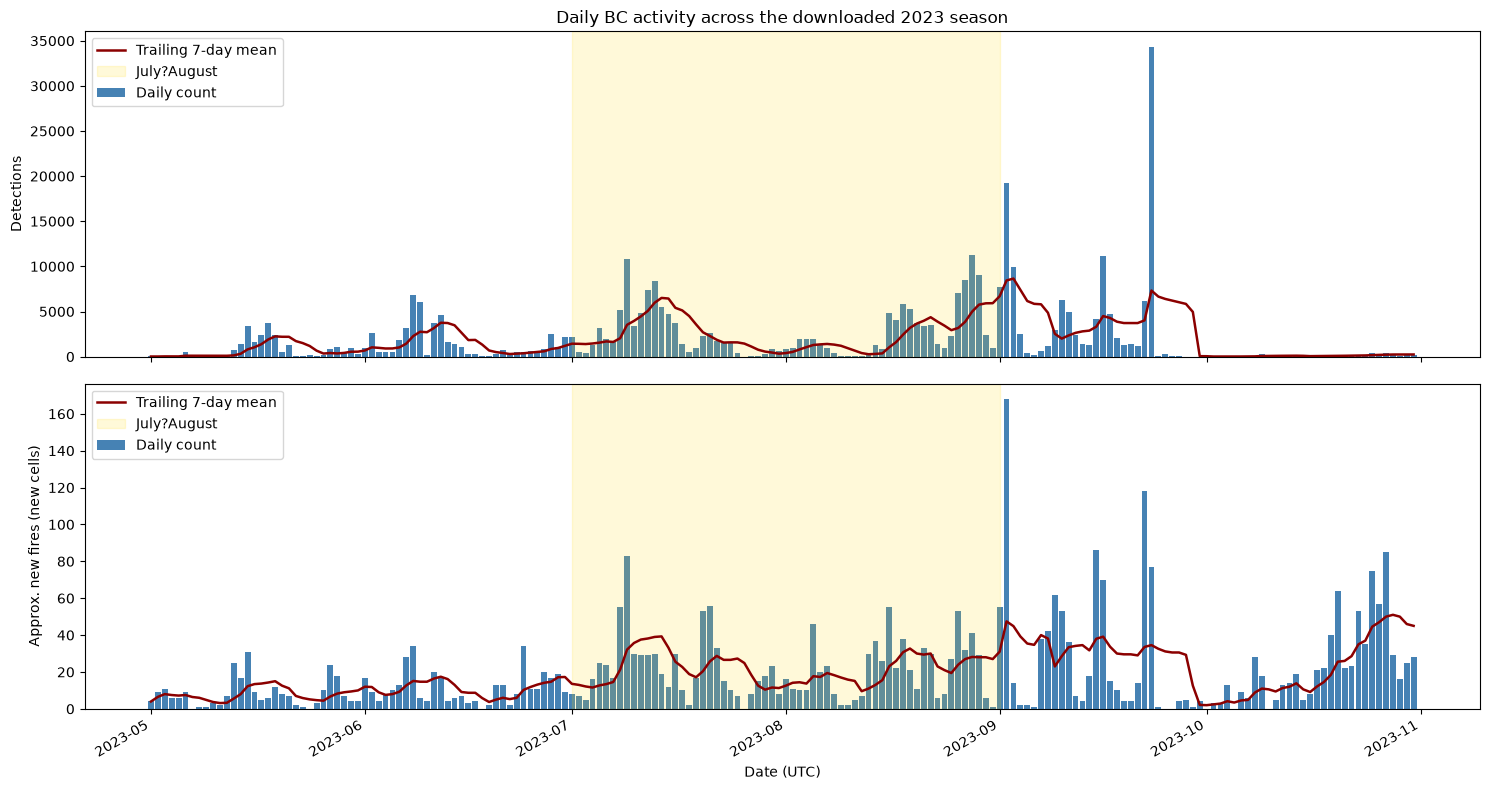

Highest detection days:


,detections,new_fires
day_utc,,
2023-09-23 00:00:00+00:00,34329,77
2023-09-02 00:00:00+00:00,19245,168
2023-08-28 00:00:00+00:00,11213,41
2023-09-16 00:00:00+00:00,11197,70
2023-07-09 00:00:00+00:00,10873,83


August 17?19 comparison:


,detections,new_fires
day_utc,,
2023-08-17 00:00:00+00:00,4034,22
2023-08-18 00:00:00+00:00,5795,38
2023-08-19 00:00:00+00:00,5275,21


Season detection peak: 2023-09-23 (34,329)


In [2]:
firms["cell_x"] = np.floor(firms.longitude / GRID_DEGREES).astype(np.int64)
firms["cell_y"] = np.floor(firms.latitude / GRID_DEGREES).astype(np.int64)
occupied = firms[["day", "cell_x", "cell_y"]].drop_duplicates()
cells_by_day = {day: set(zip(group.cell_x, group.cell_y))
                for day, group in occupied.groupby("day", sort=True)}


def count_new_cells(calendar, daily_cells, lookback=LOOKBACK_DAYS):
    history = deque()
    counts = []
    neighbours = [(dx, dy) for dx in (-1, 0, 1) for dy in (-1, 0, 1)]
    for day in calendar:
        while history and (day - history[0][0]).days > lookback:
            history.popleft()
        previous = set().union(*(cells for _, cells in history)) if history else set()
        current = daily_cells.get(day, set())
        counts.append(sum(not any((x + dx, y + dy) in previous for dx, dy in neighbours)
                          for x, y in current))
        history.append((day, current))
    return pd.Series(counts, index=calendar, dtype="int64")

activity = pd.DataFrame(index=days)
activity["detections"] = firms.groupby("day").size().reindex(days, fill_value=0)
activity["new_fires"] = count_new_cells(days, cells_by_day)
activity.index.name = "day_utc"
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
for ax, column, label in zip(axes, ["detections", "new_fires"],
                            ["Detections", "Approx. new fires (new cells)"]):
    ax.bar(activity.index, activity[column], width=0.85, color="steelblue", label="Daily count")
    ax.plot(activity.index, activity[column].rolling(ROLLING_DAYS, min_periods=1).mean(),
            color="darkred", linewidth=1.8, label="Trailing 7-day mean")
    ax.axvspan(pd.Timestamp(f"{YEAR}-07-01", tz="UTC"), pd.Timestamp(f"{YEAR}-09-01", tz="UTC"),
               color="gold", alpha=0.15, label="July?August")
    ax.set(ylabel=label)
    ax.legend(loc="upper left")
axes[0].set_title(f"Daily BC activity across the downloaded {YEAR} season")
axes[-1].set_xlabel("Date (UTC)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
print("Highest detection days:")
display(activity.nlargest(5, "detections"))
print("August 17?19 comparison:")
display(activity.loc[f"{YEAR}-08-17":f"{YEAR}-08-19"])
print(f"Season detection peak: {activity.detections.idxmax().date()} ({activity.detections.max():,})")

## 3. Rank complete 30-day windows
Test every daily start whose full window fits inside the downloaded season; truncated end-of-season windows cannot be compared fairly. END is inclusive. Peak position is zero-based, with ties resolved to the earliest maximum. Keep peaks on days 25?29 and rank by total approximate new fires, then detections, then earlier start.
Ramp-up compares mean detections on the last ten days with the first ten; the table also reports the new-fire comparison. Ramp-up is shown rather than used as an extra filter, following the requested ranking rule. Counts rank activity, not guaranteed gameplay difficulty.

In [3]:
rows = []
for offset in range(len(activity) - WINDOW_DAYS + 1):
    window = activity.iloc[offset:offset + WINDOW_DAYS]
    peak_position = int(window.detections.to_numpy().argmax())
    first_third = window.iloc[:WINDOW_DAYS // 3]
    last_third = window.iloc[-WINDOW_DAYS // 3:]
    first_mean = float(first_third.detections.mean())
    last_mean = float(last_third.detections.mean())
    rows.append({
        "START": window.index[0], "END": window.index[-1],
        "total_detections": int(window.detections.sum()),
        "total_new_fires": int(window.new_fires.sum()),
        "peak_day": window.index[peak_position], "peak_position": peak_position,
        "peak_detections": int(window.detections.max()),
        "first_third_mean_detections": first_mean,
        "last_third_mean_detections": last_mean,
        "ramps_up": last_mean > first_mean,
        "ramp_ratio": last_mean / first_mean if first_mean else np.nan,
        "new_fires_ramp_up": last_third.new_fires.mean() > first_third.new_fires.mean(),
    })
windows = pd.DataFrame(rows)
candidates = windows[windows.peak_position >= WINDOW_DAYS - PEAK_LAST_DAYS].sort_values(
    ["total_new_fires", "total_detections", "START"], ascending=[False, False, True]).reset_index(drop=True)
if candidates.empty:
    raise RuntimeError("No complete windows with a peak in the last five days.")
best = candidates.iloc[0]
print(f"Scored {len(windows)} complete windows; {len(candidates)} have a late peak.")
display(candidates.head(5)[["START", "END", "total_new_fires", "total_detections",
    "peak_day", "peak_position", "first_third_mean_detections", "last_third_mean_detections",
    "ramps_up", "ramp_ratio", "new_fires_ramp_up"]])

Scored 155 complete windows; 41 have a late peak.


,START,END,total_new_fires,total_detections,peak_day,peak_position,first_third_mean_detections,last_third_mean_detections,ramps_up,ramp_ratio,new_fires_ramp_up
0,2023-08-25 00:00:00+00:00,2023-09-23 00:00:00+00:00,1089,168810,2023-09-23 00:00:00+00:00,29,7832.6,6782.7,False,0.865958,False
1,2023-08-26 00:00:00+00:00,2023-09-24 00:00:00+00:00,1063,166582,2023-09-23 00:00:00+00:00,28,7852.8,6664.3,False,0.848653,False
2,2023-08-27 00:00:00+00:00,2023-09-25 00:00:00+00:00,1010,159818,2023-09-23 00:00:00+00:00,27,7188.0,6275.4,False,0.873038,False
3,2023-08-28 00:00:00+00:00,2023-09-26 00:00:00+00:00,978,151348,2023-09-23 00:00:00+00:00,26,6360.8,5157.2,False,0.810779,False
4,2023-08-29 00:00:00+00:00,2023-09-27 00:00:00+00:00,941,140158,2023-09-23 00:00:00+00:00,25,5305.1,4685.1,False,0.883131,False


## 4. Top three candidates
These can overlap: they are the top windows by the requested rule, not artificially separated scenarios.

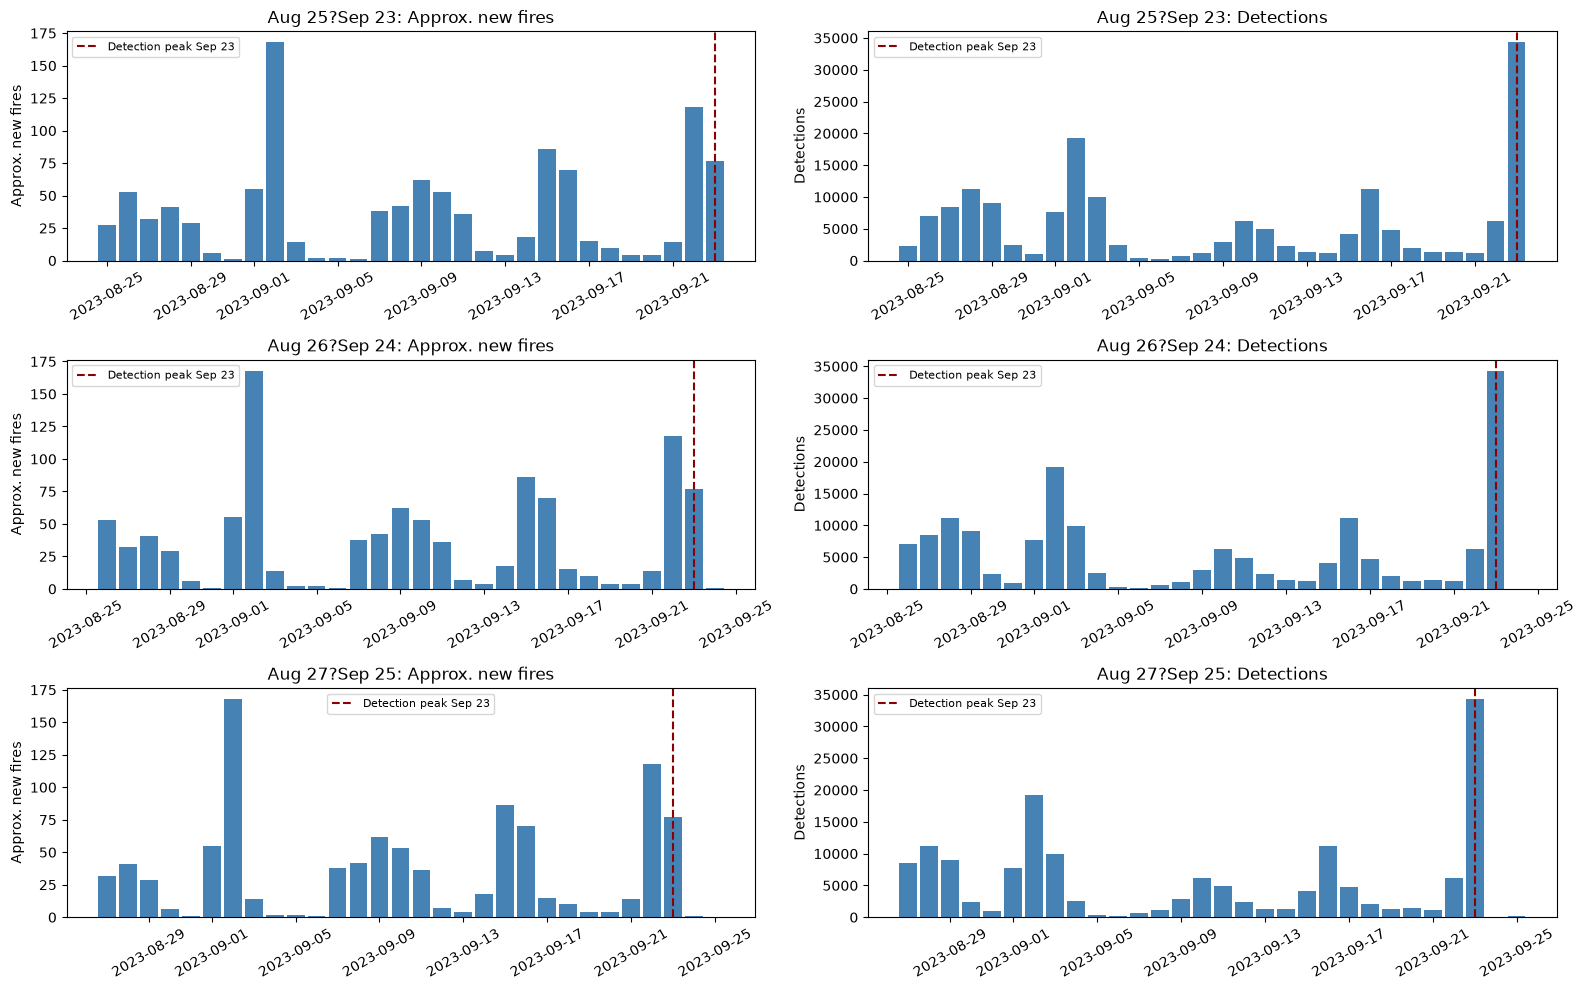

In [4]:
fig, axes = plt.subplots(min(3, len(candidates)), 2, figsize=(16, 10), squeeze=False)
for row_axes, (_, candidate) in zip(axes, candidates.head(3).iterrows()):
    window = activity.loc[candidate.START:candidate.END]
    for ax, column, label in zip(row_axes, ["new_fires", "detections"], ["Approx. new fires", "Detections"]):
        ax.bar(window.index, window[column], color="steelblue", width=0.85)
        ax.axvline(candidate.peak_day, color="darkred", linestyle="--", label=f"Detection peak {candidate.peak_day:%b %d}")
        ax.set(title=f"{candidate.START:%b %d}?{candidate.END:%b %d}: {label}", ylabel=label)
        ax.tick_params(axis="x", rotation=30)
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Best candidate map
Every detection is shown, coloured by UTC day within the window: early yellow to late dark red. This maps observed hotspots, not simulated fire growth.

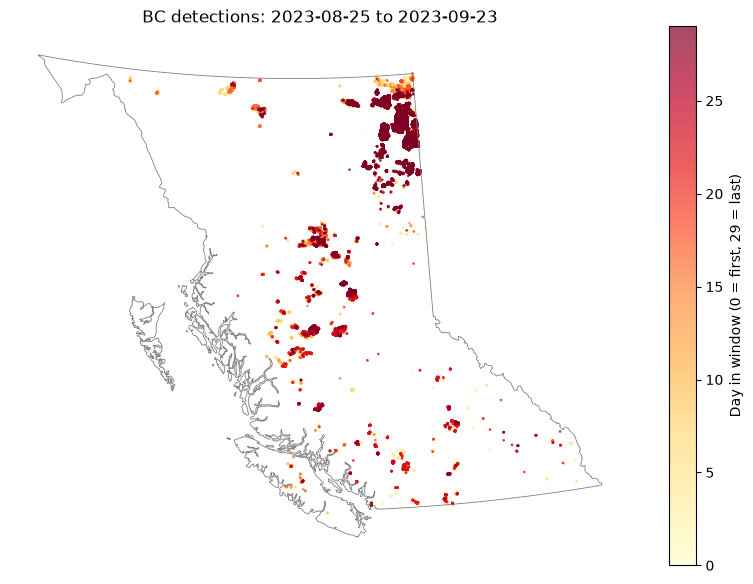

In [5]:
chosen = firms[firms.day.between(best.START, best.END)].copy()
chosen["window_day"] = (chosen.day - best.START).dt.days
bc = load_bc_boundary().to_crs("EPSG:3005")
points = gpd.GeoDataFrame(chosen, geometry=gpd.points_from_xy(chosen.longitude, chosen.latitude), crs="EPSG:4326").to_crs(bc.crs)
fig, ax = plt.subplots(figsize=(10, 10))
bc.boundary.plot(ax=ax, color="grey", linewidth=0.6)
scatter = ax.scatter(points.geometry.x, points.geometry.y, c=chosen.window_day,
    cmap="YlOrRd", norm=Normalize(0, WINDOW_DAYS - 1), s=1, alpha=0.7, rasterized=True)
fig.colorbar(scatter, ax=ax, label="Day in window (0 = first, 29 = last)", shrink=0.7)
ax.set(title=f"BC detections: {best.START:%Y-%m-%d} to {best.END:%Y-%m-%d}", aspect="equal")
ax.set_axis_off()
plt.show()

## 6. Weather coverage
Check each requested weather grid point against all 720 expected UTC hours in the recommended window. Also check missing coordinates and hourly weather values. Weather is ERA5-Seamless reanalysis through Open-Meteo. No weather or scenario files are exported.

In [6]:
weather = pd.read_parquet(PROCESSED_DIR / f"weather_bc_{YEAR}.parquet")
weather["time_utc"] = pd.to_datetime(weather.time_utc, utc=True)
if weather[["time_utc", "req_lat", "req_lon"]].isna().any().any():
    raise ValueError("Weather has missing timestamps or requested coordinates.")
ramping = candidates[candidates.ramps_up]
ramp_alternative = ramping.iloc[0] if len(ramping) else None
stop = best.END + pd.Timedelta(days=1)
expected_hours = pd.date_range(best.START, stop, freq="h", inclusive="left")
keys = ["req_lat", "req_lon"]
all_points = weather.groupby(keys).size().index
selected_weather = weather[weather.time_utc.between(best.START, stop, inclusive="left")]
coverage = selected_weather.groupby(keys).agg(rows=("time_utc", "size"), unique_hours=("time_utc", "nunique"))
coverage = coverage.reindex(all_points, fill_value=0)
valid = coverage.rows.eq(len(expected_hours)) & coverage.unique_hours.eq(len(expected_hours))
if not valid.all() or not selected_weather.time_utc.isin(expected_hours).all():
    raise ValueError(f"Incomplete or duplicate hourly weather coverage at {(~valid).sum()} grid points.")
weather_columns = ["temp_c", "rh_pct", "wind_kmh", "wind_from_deg"]
if selected_weather[weather_columns].isna().any().any():
    raise ValueError("Missing hourly weather values in the recommended window.")
print(f"Weather coverage confirmed: {len(expected_hours)} hours at each of {len(all_points)} points; no missing hours or values.")
# Printed metadata lets the recorded recommendation below reflect this executed run.
recommendation = {
    "START": best.START.strftime("%Y-%m-%d"), "END": best.END.strftime("%Y-%m-%d"),
    "peak_day": best.peak_day.strftime("%Y-%m-%d"), "peak_position": int(best.peak_position),
    "total_new_fires": int(best.total_new_fires), "total_detections": int(best.total_detections),
    "ramps_up": bool(best.ramps_up), "ramp_ratio": float(best.ramp_ratio),
    "new_fires_ramp_up": bool(best.new_fires_ramp_up),
}
print("RECOMMENDATION_JSON=" + json.dumps(recommendation))
if ramp_alternative is not None:
    alt_start = ramp_alternative.START
    alt_stop = ramp_alternative.END + pd.Timedelta(days=1)
    alt_expected = pd.date_range(alt_start, alt_stop, freq="h", inclusive="left")
    alt_weather = weather[weather.time_utc.between(alt_start, alt_stop, inclusive="left")]
    alt_coverage = alt_weather.groupby(keys).agg(rows=("time_utc", "size"), unique_hours=("time_utc", "nunique")).reindex(all_points, fill_value=0)
    if not (alt_coverage.rows.eq(len(alt_expected)) & alt_coverage.unique_hours.eq(len(alt_expected))).all() or not alt_weather.time_utc.isin(alt_expected).all():
        raise ValueError("Ramping alternative has incomplete/duplicate weather hours.")
    if alt_weather[weather_columns].isna().any().any():
        raise ValueError("Ramping alternative has missing weather values.")
    alternative = {"START": str(alt_start.date()), "END": str(ramp_alternative.END.date()),
        "peak_day": str(ramp_alternative.peak_day.date()), "peak_position": int(ramp_alternative.peak_position),
        "total_new_fires": int(ramp_alternative.total_new_fires), "total_detections": int(ramp_alternative.total_detections),
        "ramp_ratio": float(ramp_alternative.ramp_ratio), "new_fires_ramp_up": bool(ramp_alternative.new_fires_ramp_up)}
    print("Highest-ranked ramping alternative (weather coverage passed):")
    print("RAMP_ALTERNATIVE_JSON=" + json.dumps(alternative))


Weather coverage confirmed: 720 hours at each of 569 points; no missing hours or values.
RECOMMENDATION_JSON={"START": "2023-08-25", "END": "2023-09-23", "peak_day": "2023-09-23", "peak_position": 29, "total_new_fires": 1089, "total_detections": 168810, "ramps_up": false, "ramp_ratio": 0.8659576641217475, "new_fires_ramp_up": false}
Highest-ranked ramping alternative (weather coverage passed):
RAMP_ALTERNATIVE_JSON={"START": "2023-08-05", "END": "2023-09-03", "peak_day": "2023-09-02", "peak_position": 28, "total_new_fires": 856, "total_detections": 118274, "ramp_ratio": 12.430725281701317, "new_fires_ramp_up": true}


## 7. Recommendation

For the **ramp-up goal**, recommend **START = 2023-08-05** and **END = 2023-09-03** (inclusive UTC dates, 30 days).

- Peak detections: **2023-09-02**, window position **28** (0?29).
- Total approximate new fires: **856 newly active cells**.
- Total detections: **118,274**.
- Last-third mean detections are **12.43 times** the first-third mean; approximate new-fire counts also ramp up.
- All **720 hourly weather samples** are present at each of **569 requested grid points**, with no missing weather values.

The strict count ranking puts **2023-08-25?2023-09-23** first: **1,089** new cells and **168,810** detections, peaking on **2023-09-23** (position **29**). However, its last-third activity is only **0.87 times** its first third, so it does **not** ramp up. The top-five table and top-three plots retain that requested ranking; the map shows its highest-ranked candidate.

The province-wide detection peak is September 23, not August 17?19. A regional focus may peak differently. Newly active cells are an ignition approximation, not confirmed separate fires. First-season lookback is incomplete. **The final window remains your choice.**

This markdown records the executed run. If inputs or settings change, rerun and use the refreshed tables and recommendation metadata above. No data or level files are exported.

## 8. Additional comparison: August 4?September 2
This appended comparison examines geography, pre-window detections, and sensitivity of the approximate new-fire count. It uses the same 0.05-degree daily-cell rule and writes no files. Pre-window occupied cells are observation proxies, not confirmed fires still burning at the level start.

In [7]:
# Compatibility with the appended focus-window comparison below.
import matplotlib.dates as mdates
season = days
CELL_DEG = GRID_DEGREES
QUIET_DAYS = LOOKBACK_DAYS
fires = firms
daily = activity
cell_days = occupied.rename(columns={"cell_x": "ix", "cell_y": "iy"}).copy()
cell_days["day_idx"] = (cell_days.day - days[0]).dt.days
active = set(map(tuple, cell_days[["day_idx", "ix", "iy"]].to_numpy()))
cell_days["new"] = [not any((d - back, x + dx, y + dy) in active
    for back in range(1, QUIET_DAYS + 1) for dx in (-1, 0, 1) for dy in (-1, 0, 1))
    for d, x, y in cell_days[["day_idx", "ix", "iy"]].to_numpy()]
assert cell_days[cell_days["new"]].groupby("day").size().reindex(days, fill_value=0).equals(activity.new_fires)


In [8]:
FOCUS_START = pd.Timestamp(f"{YEAR}-08-04", tz="UTC")
FOCUS_END = pd.Timestamp(f"{YEAR}-09-02", tz="UTC")
NORTH_LATITUDE = 55.0
PRE_DAYS = 7
focus_days = pd.date_range(FOCUS_START, FOCUS_END, freq="D")


def new_cells(calendar, radius=1, lookback=LOOKBACK_DAYS):
    """Same rule as count_new_cells, but returns the cells and takes a neighbourhood radius."""
    neighbours = [(dx, dy) for dx in range(-radius, radius + 1) for dy in range(-radius, radius + 1)]
    rows = []
    for day in calendar:
        previous = set().union(*(cells_by_day.get(day - pd.Timedelta(days=back), set())
                                 for back in range(1, lookback + 1)))
        rows += [(day, x, y) for x, y in cells_by_day.get(day, set())
                 if not any((x + dx, y + dy) in previous for dx, dy in neighbours)]
    return pd.DataFrame(rows, columns=["day", "cell_x", "cell_y"])


def add_centres(cells):
    cells = cells.copy()
    cells["longitude"] = (cells.cell_x + 0.5) * GRID_DEGREES
    cells["latitude"] = (cells.cell_y + 0.5) * GRID_DEGREES
    cells["region"] = np.where(cells.latitude >= NORTH_LATITUDE, "north", "south")
    return cells


focus_new = add_centres(new_cells(focus_days))
focus_new["window_day"] = (focus_new.day - FOCUS_START).dt.days
focus_firms = firms[firms.day.between(FOCUS_START, FOCUS_END)]
# The cell-level count must reproduce the daily totals from section 2.
assert len(focus_new) == activity.loc[FOCUS_START:FOCUS_END, "new_fires"].sum()
print(f"{FOCUS_START.date()} to {FOCUS_END.date()}: {len(focus_new):,} approx. new fires, "
      f"{len(focus_firms):,} detections")

2023-08-04 to 2023-09-02: 852 approx. new fires, 110,234 detections


### North vs south
Split at 55°N. New fires use the grid-cell centre; detections use their own latitude.

In [9]:
split = pd.DataFrame({
    "new_fires": focus_new.region.value_counts(),
    "detections": pd.Series(np.where(focus_firms.latitude >= NORTH_LATITUDE, "north", "south")).value_counts(),
}).reindex(["north", "south"], fill_value=0)
split["new_fires_pct"] = (100 * split.new_fires / split.new_fires.sum()).round(1)
split["detections_pct"] = (100 * split.detections / split.detections.sum()).round(1)
split.loc["total"] = split.sum()
display(split.astype({"new_fires": int, "detections": int}))

,new_fires,detections,new_fires_pct,detections_pct
north,426,62582,50.0,56.8
south,426,47652,50.0,43.2
total,852,110234,100.0,100.0


### Already burning at level start
Grid cells with any detection in the 7 days before Aug 4. These fires would already exist at time zero.

In [10]:
pre_days = pd.date_range(FOCUS_START - pd.Timedelta(days=PRE_DAYS), periods=PRE_DAYS, freq="D")
pre_cells = add_centres(pd.DataFrame(
    sorted(set().union(*(cells_by_day.get(day, set()) for day in pre_days))),
    columns=["cell_x", "cell_y"]))
pre_regions = pre_cells.region.value_counts().reindex(["north", "south"], fill_value=0)
print(f"Cells with detections {pre_days[0].date()} to {pre_days[-1].date()}: {len(pre_cells):,} "
      f"(north {pre_regions['north']:,}, south {pre_regions['south']:,})")

Cells with detections 2023-07-28 to 2023-08-03: 236 (north 65, south 171)


### Map
Grey squares: cells already burning before the window. Coloured dots: new fires by UTC day, early yellow to late dark red. The dashed line is 55°N.

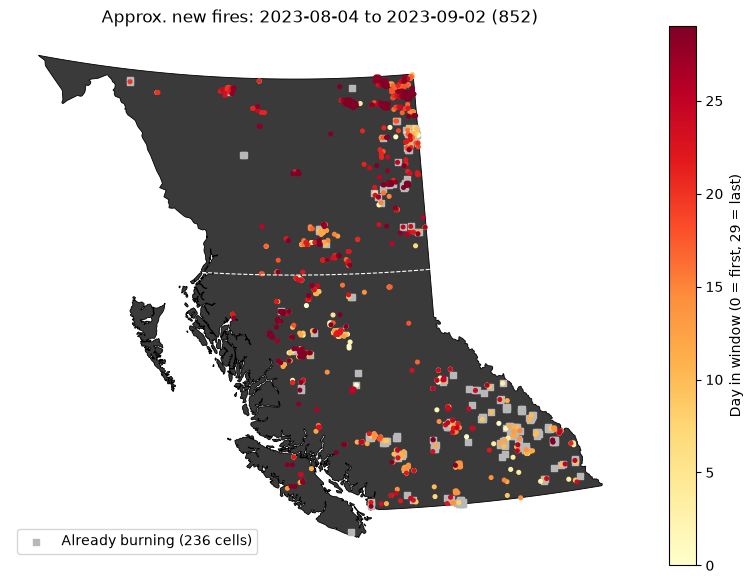

In [16]:
def project(cells):
    return gpd.GeoSeries(gpd.points_from_xy(cells.longitude, cells.latitude), crs="EPSG:4326").to_crs(bc.crs)


parallel = gpd.GeoSeries(gpd.points_from_xy(np.linspace(-139, -114, 100), np.full(100, NORTH_LATITUDE)),
                         crs="EPSG:4326").to_crs(bc.crs)
pre_xy, new_xy = project(pre_cells), project(focus_new)
fig, ax = plt.subplots(figsize=(10, 10))
bc.plot(ax=ax, color="#3a3a3a", edgecolor="black", linewidth=0.6)  # dark land so yellow is visible
limits = ax.axis()
ax.plot(parallel.x, parallel.y, color="white", linestyle="--", linewidth=0.8)
ax.scatter(pre_xy.x, pre_xy.y, color="#b8b8b8", marker="s", s=22,
           label=f"Already burning ({len(pre_cells):,} cells)")
order = focus_new.window_day.to_numpy().argsort(kind="stable")
scatter = ax.scatter(new_xy.x.to_numpy()[order], new_xy.y.to_numpy()[order],
    c=focus_new.window_day.to_numpy()[order], cmap="YlOrRd", norm=Normalize(0, WINDOW_DAYS - 1), s=7)
fig.colorbar(scatter, ax=ax, label="Day in window (0 = first, 29 = last)", shrink=0.7)
ax.axis(limits)
ax.legend(loc="lower left")
ax.set(title=f"Approx. new fires: {FOCUS_START:%Y-%m-%d} to {FOCUS_END:%Y-%m-%d} ({len(focus_new):,})",
       aspect="equal")
ax.set_axis_off()
plt.show()

### How much is blow-up-day over-counting?
Section 2 calls a cell new when its eight neighbours (about 5 km) were empty for three days, so a fast fire front can register as many new fires. Repeat the count with a two-cell neighbourhood (about 10 km) and a five-day lookback.

New fires, 1 cell / 3 days:  852
New fires, 2 cells / 5 days: 469 (45% fewer)
Days with the most new fires under the original settings:


,detections,new_1cell_3day,new_2cell_5day
2023-09-02 00:00:00+00:00,19245,168,78
2023-08-16 00:00:00+00:00,4783,55,36
2023-09-01 00:00:00+00:00,7694,55,15
2023-08-26 00:00:00+00:00,7008,53,18
2023-08-05 00:00:00+00:00,1937,46,30
2023-08-28 00:00:00+00:00,11213,41,27


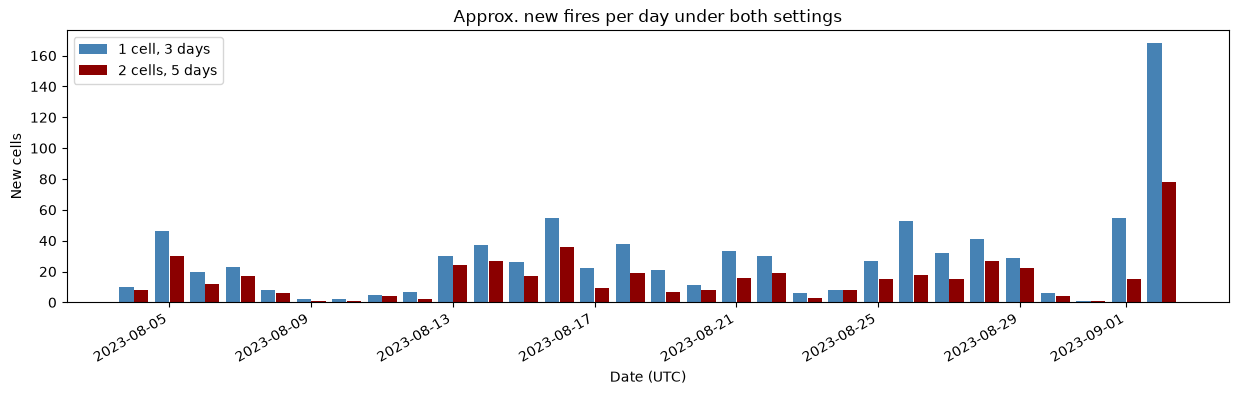

In [12]:
wide_new = new_cells(focus_days, radius=2, lookback=5)
compare = pd.DataFrame({
    "detections": activity.loc[FOCUS_START:FOCUS_END, "detections"],
    "new_1cell_3day": focus_new.groupby("day").size().reindex(focus_days, fill_value=0),
    "new_2cell_5day": wide_new.groupby("day").size().reindex(focus_days, fill_value=0),
})
narrow_total, wide_total = int(compare.new_1cell_3day.sum()), int(compare.new_2cell_5day.sum())
print(f"New fires, 1 cell / 3 days:  {narrow_total:,}")
print(f"New fires, 2 cells / 5 days: {wide_total:,} ({1 - wide_total / narrow_total:.0%} fewer)")
print("Days with the most new fires under the original settings:")
display(compare.nlargest(6, "new_1cell_3day"))

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(compare.index - pd.Timedelta(hours=5), compare.new_1cell_3day, width=0.4,
       color="steelblue", label="1 cell, 3 days")
ax.bar(compare.index + pd.Timedelta(hours=5), compare.new_2cell_5day, width=0.4,
       color="darkred", label="2 cells, 5 days")
ax.set(title="Approx. new fires per day under both settings", ylabel="New cells", xlabel="Date (UTC)")
ax.legend()
fig.autofmt_xdate()
plt.show()